# Mini-Project 3

**Student:** *Kim Concepcion Nielsen*

**Course:** *Numerical Scientific Computing 2026*

---

## Link to GitHub repository
[GitHub Repository Link](https://github.com/NDS8-TCP/nsc-kim.git)

## Hardware Specs
I got another laptop after MP2, so the specifications have been updated in this report

* CPU Model: Apple M5
* CPU Cores: 10
* RAM: 24GB

For the **Section 3 GPU performance** section in this report, I decided to use another machine to complete the exercises and milestones as the GPU on my laptop does not support 64-bit floating points.

The relevant specifications of the other machine is listed below:
* GPU Model: NVIDIA GeForce RTX 2080 Ti
* GPU Memory: 11GB
* GPU Base Clock: 1350 MHz

## Operating System Information
* System version: macOS Tahoe 26.4.1

## Library versions
* Python: 3.11.15

### Python packages (relevant for Mandelbrot / performance)

| Package     | Version |
|------------|--------|
| numpy      | 2.4.3 |
| numba      | 0.64.0 |
| matplotlib | 3.10.8 |
| pytest| 9.0.3 |
| pytest-cov| 7.1.0 |
| ruff| 0.15.10 |
| pyopencl| 2026.1.1 |

### Measurement Methodology
The test suite code in **Section 2: Testing & Documentation** has been executed from .py files, as I have experienced issues running multiprocessing code directly from a Jupyter Notebook cell. One just has to enter the **all_mandelbrot_implementations** folder in the **nsc-kim** repository and run **pytest -v** to run test suite for Numba, Multiprocessing and Local Dask implementations. Keep in mind, that results presented in this report might vary depending on what hardware and software versions are used to run the code in this notebook. All relevant applied hardware and software versions have been documented in this notebook.

---

# Section 1: Numerical accuracy

## Exercises

##### Exercise 1: Machine Epsilon

In [23]:
import numpy as np

def find_machine_epsilon(dtype):    
    eps = dtype(1.0)
    while dtype(1.0) + eps / dtype(2.0) != dtype(1.0):
        eps = eps / dtype(2.0)
    return eps

for dtype in [np.float16, np.float32, np.float32]:
    computed_eps = find_machine_epsilon(dtype)
    np_eps = np.finfo(dtype).eps
    
    print(f'{dtype.__name__}:')
    print(f'    Computed: {float(computed_eps):4e}')
    print(f'    np.fino: {float(np_eps):4e}')
    print()


float16:
    Computed: 9.765625e-04
    np.fino: 9.765625e-04

float32:
    Computed: 1.192093e-07
    np.fino: 1.192093e-07

float32:
    Computed: 1.192093e-07
    np.fino: 1.192093e-07



##### Exercise 2: Catastrophic Cancelation

In [ ]:
import numpy as np

def quadratic_naive(a, b, c):
    t = type(a) # np.float32 or np.float64
    disc = t(np.sqrt(b*b - t(4)*a*c)) # b*b not b**2; t() casts literals and sqrt
    x1 = (-b + disc) / (t(2)*a)
    x2 = (-b - disc) / (t(2)*a)
    return x1, x2

def quadratic_stable(a, b, c):
    t = type(a)
    disc = t(np.sqrt(b*b - t(4)*a*c))
    if b > 0:
        x1 = (-b - disc) / (t(2)*a) # pick sign that avoids cancellation
    else:
        x1 = (-b + disc) / (t(2)*a)
    x2 = c / (a * x1) # Vieta’s formula: x1 * x2 = c/a
    return x1, x2

true_small = 1.0 / 10000.0001 # ~ 1e-4

for dtype in [np.float16, np.float32, np.float64]:
    a, b, c = dtype(1.0), dtype(-10000.0001), dtype(1.0)
    _, x2_naive = quadratic_naive(a, b, c)
    _, x2_stable = quadratic_stable(a, b, c)
    err_naive = abs(float(x2_naive) - true_small) / true_small
    err_stable = abs(float(x2_stable) - true_small) / true_small
    print(f"{dtype.__name__}: naive={err_naive:.2e} stable={err_stable:.2e}")


float16: naive=inf stable=1.00e+00
float32: naive=1.00e+00 stable=1.53e-08
float64: naive=1.20e-08 stable=1.00e-08


/var/folders/v2/99ntmfk90bb_y5jznq4rq7f40000gn/T/ipykernel_43697/394785883.py:5: RuntimeWarning: overflow encountered in scalar multiply
  disc = t(np.sqrt(b*b - t(4)*a*c)) # b*b not b**2; t() casts literals and sqrt
/var/folders/v2/99ntmfk90bb_y5jznq4rq7f40000gn/T/ipykernel_43697/394785883.py:12: RuntimeWarning: overflow encountered in scalar multiply
  disc = t(np.sqrt(b*b - t(4)*a*c))


##### Exercise 3: Error Accumulation

In [ ]:
import numpy as np

n_values = [10, 100, 1_000, 10_000, 100_000]

for dtype in [np.float16, np.float32, np.float64]:
    print(f"\n{dtype.__name__}:")
    for n in n_values:
        total = dtype(0.0)
        for _ in range(n):
            total += dtype(0.1)
        expected = n * 0.1
        rel_error = abs(float(total) - expected) / expected
        print(f" n={n:>7d}: result={float(total):.10f} rel_error={rel_error:.2e}")



float16:
 n=     10: result=1.0000000000 rel_error=0.00e+00
 n=    100: result=10.0781250000 rel_error=7.81e-03
 n=   1000: result=105.1875000000 rel_error=5.19e-02
 n=  10000: result=256.0000000000 rel_error=7.44e-01
 n= 100000: result=256.0000000000 rel_error=9.74e-01

float32:
 n=     10: result=1.0000001192 rel_error=1.19e-07
 n=    100: result=10.0000019073 rel_error=1.91e-07
 n=   1000: result=99.9990463257 rel_error=9.54e-06
 n=  10000: result=999.9028930664 rel_error=9.71e-05
 n= 100000: result=9998.5566406250 rel_error=1.44e-04

float64:
 n=     10: result=1.0000000000 rel_error=1.11e-16
 n=    100: result=10.0000000000 rel_error=1.95e-15
 n=   1000: result=100.0000000000 rel_error=1.41e-14
 n=  10000: result=1000.0000000002 rel_error=1.59e-13
 n= 100000: result=10000.0000000188 rel_error=1.88e-12


Does the error grow with n? Is float64 better?

*When n grows, the relative error increases. This is especially easy to see, when using float16. If we use float32 the error decreases and the best results are achieved using float64. This is naturally due to a much lower machine epsilon and due to more bits avaiable to represent the floating point number*

Why does 0.1 cause problems? It has no exact binary representation — like 1/3 in decimal, it repeats forever

*0.1 cannot be represented precisely with any floating point number. Because the floating point number continues forever, it must be rounded to a fixed amount of bits in the mantissa, causing a rounding error. When we repeatedly add 0.1 to a result, the rounding error accumulates and becomes more and more unstable*

## Milestones

##### Milestone 1: Mandelbrot Trajectory Divergence

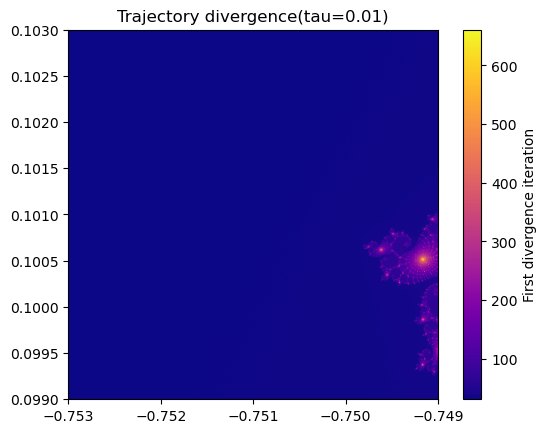

Total pixels: 262144
Number of diverging pixels before max iteration: 262144
Portion Percentage: 100.00%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N, MAX_ITER, TAU = 512, 1000, 0.01
x = np.linspace(-0.7530, -0.7490, N)
y = np.linspace( 0.0990, 0.1030, N)

C64 = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
C32 = C64.astype(np.complex64)
z32 = np.zeros_like(C32)
z64 = np.zeros_like(C64)

diverge = np.full((N, N), MAX_ITER, dtype=np.int32)
active = np.ones((N, N), dtype=bool)

for k in range(MAX_ITER):
    if not active.any(): 
        break
    
    z32[active] = z32[active]**2 + C32[active]
    z64[active] = z64[active]**2 + C64[active]
    diff = (np.abs(z32.real.astype(np.float64) - z64.real)
        + np.abs(z32.imag.astype(np.float64) - z64.imag))
    newly = active & (diff > TAU)
    diverge[newly] = k
    active[newly] = False

plt.imshow(diverge, cmap='plasma', origin='lower',
    extent=[-0.7530, -0.7490, 0.0990, 0.1030])

plt.colorbar(label='First divergence iteration')
plt.title(f'Trajectory divergence(tau={TAU})')
plt.show()

# Calculations
total_pixels = N*N
diverged_pixels  = np.sum(diverge < MAX_ITER) # find pixels diverging before max iterations
portion_diverged = diverged_pixels / total_pixels
print(f'Total pixels: {N*N}')
print(f'Number of diverging pixels before max iteration: {diverged_pixels}')
print(f'Portion Percentage: {portion_diverged*100.0:.2f}%')


**Observations to make**

* What fraction of pixels diverge before max iter?

*According to the calculation above, all the pixels diverge before 1000 iterations.*

* Where do trajectories diverge early?

*According to the colormap image above, the earliest divergences appear in the darkest purple areas. The later divergences appear in the red and orange areas of the Mandelbrot plot. In the actual Mandelbrot set, the earliest divergences seem to appear around the edges of the figure.*

* Does early divergence correlate with high escape iteration counts?

*Yes, early divergence correlates with high escape iteration counts. Early trajectory divergence mostly happens near the edges of the Mandelbrot set, which also corresponds to regions with high escape iteration counts*

##### Milestone 2: Mandelbrot Sensitivity Map

eps32: 1.1920928955078125e-07, delta: [[9.05370814e-08 9.05361562e-08 9.05352310e-08 ... 9.00661844e-08
  9.00652593e-08 9.00643342e-08]
 [9.05372030e-08 9.05362779e-08 9.05353527e-08 ... 9.00663067e-08
  9.00653816e-08 9.00644565e-08]
 [9.05373247e-08 9.05363995e-08 9.05354743e-08 ... 9.00664290e-08
  9.00655039e-08 9.00645788e-08]
 ...
 [9.06002188e-08 9.05992943e-08 9.05983698e-08 ... 9.01296517e-08
  9.01287272e-08 9.01278028e-08]
 [9.06003453e-08 9.05994207e-08 9.05984962e-08 ... 9.01297788e-08
  9.01288544e-08 9.01279299e-08]
 [9.06004717e-08 9.05995472e-08 9.05986227e-08 ... 9.01299059e-08
  9.01289815e-08 9.01280570e-08]]


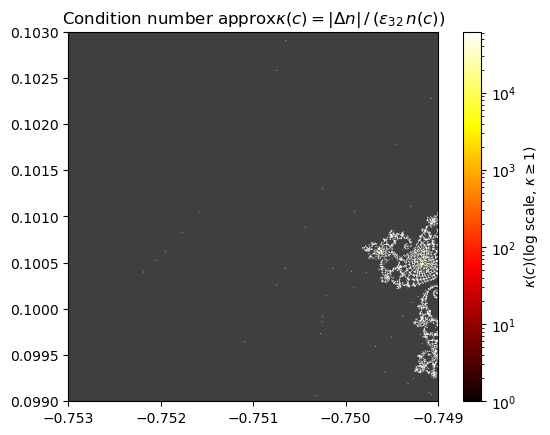

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

N, MAX_ITER = 512, 1000
x = np.linspace(-0.7530, -0.7490, N)
y = np.linspace( 0.0990, 0.1030, N)
C = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
eps32 = float(np.finfo(np.float32).eps)
delta = np.maximum(eps32 * np.abs(C), 1e-10)

print(f'eps32: {eps32}, delta: {delta}')

def escape_count(C, max_iter):
    z = np.zeros_like(C); cnt = np.full(C.shape, max_iter, dtype=np.int32)
    esc = np.zeros(C.shape, dtype=bool)

    for k in range(max_iter):
        z[~esc] = z[~esc]**2 + C[~esc]
        newly = ~esc & (np.abs(z) > 2.0)
        cnt[newly] = k; esc[newly] = True
    return cnt

n_base = escape_count(C, MAX_ITER).astype(float)
n_perturb = escape_count(C + delta, MAX_ITER).astype(float)
dn = np.abs(n_base - n_perturb)
kappa = np.where(n_base > 0, dn / (eps32 * n_base), np.nan)
cmap_k = plt.cm.hot.copy(); cmap_k.set_bad('0.25')
vmax = np.nanpercentile(kappa, 99)

plt.imshow(kappa, cmap=cmap_k, origin='lower',
        extent=[-0.7530, -0.7490, 0.0990, 0.1030],
        norm=LogNorm(vmin=1, vmax=vmax))

plt.colorbar(label=r'$\kappa(c)$(log scale, $\kappa\geq1$)' )
plt.title(r'Condition number approx$\kappa(c)= |\Delta n|\,/\,(\varepsilon_{32}\,n(c))$')
plt.show()


Observations:

* Where is $\kappa$ largest? Does it match the boundary in M1?

*The condition value $\kappa$ value is largest near the edges of the Mandelbrot set. This is highlighted by the hot colormap. The white areas indicate the highest condition values and we can see that the edges are all white on the plot above. This also matches what we observed in M1. Here, the Plasma colormap indicated that the boundaries contained the earliest divergences. This suggests that these areas of the Mandelbrot set are the most sensitive to small changes in the input*

* What is $\kappa$ for interior pixels (n=MAX_ITER)?

*For interior pixels, where n=max_iter, the condition number $\kappa$ is approximately zero. These pixel areas of the Mandelbrot set are the most numerically insensitive. In other words, these areas are not as sensitive to small changes in the input compared to the edges of the Mandelbrot set.*

---

# Section 2: Testing and documentation

Setup ipytest

In [ ]:
import ipytest
ipytest.autoconfig()

## Exercises

##### Exercise 1: Extract and Test

In [ ]:
import math

def mandelbrot_pixel(c: complex, max_iter: int) -> int:
    z = 0j
    for n in range(max_iter):
        if z.real*z.real + z.imag*z.imag > 4.0:
            return n
        z = z*z + c
    return max_iter

# Naive mandelbrot pixel check method
def naive_mandelbrot(c, max_iteration) -> int:
    # Initialize z value before loop
    z = 0

    for n in range(max_iteration):
        # compute: z_{n+1} = z_n^2 + c
        z = z**2 + c
        # Check if new z value exceeds 2
        if math.sqrt( z.real**2 + z.imag**2 ) > 2:
            return n
    
    # If we reach max_iteration and z has still not diverged, we return max_iteration
    return max_iteration


ipytest output from notebook

In [ ]:
%%ipytest -v

def test_origin():
    assert mandelbrot_pixel(0+0j, 100) == 100
    assert naive_mandelbrot(0+0j, 100) == 100

def test_far_outside():
    assert mandelbrot_pixel(5.0+0j, 100) == 1


======================================= test session starts ========================================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0
rootdir: /Users/kimnielsen/Library/CloudStorage/OneDrive-AalborgUniversitet/git/aau-repos/2_semester/nsc-kim-new/mp3
plugins: anyio-4.12.1, cov-7.1.0
collected 2 items

t_1815c240c9cb409c8df4a0ecc5f21578.py ..                                                     [100%]

======================================== 2 passed in 0.01s =========================================


Output using pytest -v

```python
=============================================================================================== test session starts ===============================================================================================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/kimnielsen/miniforge3/envs/nsc2026/bin/python3.11
cachedir: .pytest_cache
rootdir: /Users/kimnielsen/Library/CloudStorage/OneDrive-AalborgUniversitet/git/aau-repos/2_semester/nsc-kim-new/mp3
plugins: anyio-4.12.1, cov-7.1.0
collected 2 items                                                                                                                                                                                                 

test_mandelbrot_pixel.py::test_origin PASSED                                                                                                                                                                [ 50%]
test_mandelbrot_pixel.py::test_far_outside PASSED                                                                                                                                                           [100%]

================================================================================================ 2 passed in 0.00s ================================================================================================
```

##### Exercise 2: Add a Docstring

In [ ]:
def mandelbrot_pixel(c: complex, max_iter: int) -> int:
    """Find the number of iterations for one point in the complex plane.
    
    Iterates z_{n+1} = z_n^2 + c starting from 0 until |z| > 2 or max_iter is reached.
    
    Parameters
    ----------
    c : complex
        Point in the complex plane to check.
    
    max_iter : int
        The maximum number of iterations if trajectory does not escape.

    Returns:
    ----------
    int 
        Iteration count if z_{real}^2 + z_{imag}^2 > 4, else max_iter
    """
    z = 0j
    for n in range(max_iter):
        if z.real*z.real + z.imag*z.imag > 4.0:
            return n
        z = z*z + c
    return max_iter


Display method docs with markdown

In [ ]:
from IPython.display import display, Markdown
display(Markdown(mandelbrot_pixel.__doc__))


Find the number of iterations for one point in the complex plane.

    Iterates z_{n+1} = z_n^2 + c starting from 0 until |z| > 2 or max_iter is reached.

    Parameters
    ----------
    c : complex
        Point in the complex plane to check.

    max_iter : int
        The maximum number of iterations if trajectory does not escape.

    Returns:
    ----------
    int 
        Iteration count if z_{real}^2 + z_{imag}^2 > 4, else max_iter
    

##### Exercise 3: Branch Coverage Report

**Generate coverage report with:**

```sh
pytest --cov=. --cov-branch --cov-report=term-missing -v
```

**Coverage report:**

```python
=============================================================================================== test session starts ===============================================================================================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/kimnielsen/miniforge3/envs/nsc2026/bin/python3.11
cachedir: .pytest_cache
rootdir: /Users/kimnielsen/Library/CloudStorage/OneDrive-AalborgUniversitet/git/aau-repos/2_semester/nsc-kim-new/mp3
plugins: anyio-4.12.1, cov-7.1.0
collected 2 items                                                                                                                                                                                                 

test_mandelbrot_pixel.py::test_origin PASSED                                                                                                                                                                [ 50%]
test_mandelbrot_pixel.py::test_far_outside PASSED                                                                                                                                                           [100%]

================================================================================================= tests coverage ==================================================================================================
________________________________________________________________________________ coverage: platform darwin, python 3.11.15-final-0 ________________________________________________________________________________

Name                       Stmts   Miss Branch BrPart  Cover   Missing
----------------------------------------------------------------------
mandelbrot_pixel.py           15      1      8      1    91%   22
test_mandelbrot_pixel.py       6      0      0      0   100%
----------------------------------------------------------------------
TOTAL                         21      1      8      1    93%
================================================================================================ 2 passed in 0.01s ================================================================================================
```

## Milestones

##### Milestone 1: Test Suite

Below I have shown all the Mandelbrot implementations, but I have added docstrings to further document all the implementations.
For testing, my test suite is based on the Numba, Multiprocessing and Local Dask implementations. Instead of 3 test cases, there are a total of 29 test cases.

###### **Naive**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import statistics
import math
import time
from typing import Callable, Any

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N              = 1024  # Same width & height
x_min          = -2.0  # min point on real axis
x_max          = 1.0   # max point on real axis
y_min          = -1.5  # min point on imaginary axis
y_max          = 1.5   # max point on imaginary axis
max_iter       = 100   # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.
mandelbrot_set = [ [0 for _ in range(N)] for _ in range(N) ] # reset mandelbrot set

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------
def naive_mandelbrot(c:complex, max_iter:int) -> int:
    """ This function computes Mandelbrot algorithm: z_{n+1} = z_n^2 + c
    The function checks if complex number "c" diverges by iterating over "z_{n+1} = z_n^2 + c"
    At each iteration, the function checks if the magnitude of the new z_{n+1} value exceeds 2, which means that "c" is NOT in the Mandelbrot set and results in divergence.
    The function returns the amount of iterations required before divergence or max iterations if no divergence is detected.
    
    Parameters
    ----------
    c : complex
        Point in complex plane with real and imaginary part.
    
    Returns
    ----------
    int
        Returns n if it diverges, else max_iter
    """
    
    # Initialize z value before loop
    z = 0

    for n in range(max_iter):
        # compute: z_{n+1} = z_n^2 + c
        z = z**2 + c
        # Check if new z value exceeds 2
        if math.sqrt( z.real**2 + z.imag**2 ) > 2:
            return n
    
    # If we reach max_iter and z has still not diverged, we return max_iter
    return max_iter

def create_grid() -> list:
    """Create grid or complex plane of real and imaginary axes. Represent axes as lists.
    We create two lists -> one for real part and one for imaginary part.
    
    Returns
    ----------
    list
        list of two lists. 
        - The first list contains the real axis values (x)
        - The second list contains the imaginary axis values (y)
    """
    dx = (x_max - x_min) / (N - 1)
    dy = (y_max - y_min) / (N - 1)
    x  = [ x_min + i*dx for i in range(N)]
    y  = [ 1j * (y_min + i*dy) for i in range(N)]
    C  = [x,y] # Form complex numbers
    
    return C

def naive_compute_mandelbrot(C_grid:list) -> list:
    """Compute Mandelbrot set by iterating over all pixels and applying mandelbrot function on corresponding complex number.
    
    Parameters
    ----------
    C_grid : list
        list of two lists.
        - The first list contains the real axis values (x)
        - The second list contains the imaginary axis values (y)
    
    Returns
    ----------
    list
        list with N number of lists. Each list is also N long. 
        Each element of these lists are escape counts or max_iter depending on if the pixel did not diverge before reaching max_iter.
    """
    # Loop over all grid complex values and check for divergence with mandelbrot function
    for i in range(N):
        for j in range(N):
            c = C_grid[0][j] + C_grid[1][i] # Form complex number for current pixel
            mandelbrot_set[i][j] = naive_mandelbrot( c, max_iter )
    return mandelbrot_set

def benchmark ( func:Callable[..., Any], *args , n_runs:int=3) -> tuple[float, Any]:
    """Time func , return median of n_runs.
    
    Parameters
    ----------
    func : Callable[..., Any]
        The function with arbitrary arguments to benchmark.
    args :
        Arguments for function to benchmark.
    n_runs : int
        Number of times to run function. Default is 3.
    
    Returns
    ----------
    tuple[float, Any]
        tuple with time median of n_runs and result of benchmarked function.
    """
    times = []
    for _ in range ( n_runs ):
        t0 = time . perf_counter ()
        result = func (* args )
        times . append ( time . perf_counter () - t0 )
    
    median_t = statistics . median ( times )
    
    print (f" Median : { median_t :.4f}s "
        f"( min ={ min( times ):.4f}, max ={ max( times ):.4f})")
    
    return median_t, result

# ----------------------------------------------------------------------------------------------------
# Example usage
# ----------------------------------------------------------------------------------------------------
naive_C_grid = create_grid()
t, M = benchmark(naive_compute_mandelbrot, naive_C_grid)

# Plot results
plt.imshow( M, extent=(x_min, x_max, y_min, y_max), cmap='plasma' )
plt.colorbar()
plt.title('Mandelbrot plot')
plt.xlabel('Real axis')
plt.ylabel('Imaginary axis')
plt.show()


###### **Numpy**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import statistics
import time
from typing import Callable, Any

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N              = 1024  # Same width & height
x_min          = -2.0  # min point on real axis
x_max          = 1.0   # max point on real axis
y_min          = -1.5  # min point on imaginary axis
y_max          = 1.5   # max point on imaginary axis
max_iter       = 100   # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.
mandelbrot_set = [ [0 for _ in range(N)] for _ in range(N) ] # reset mandelbrot set

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------
def numpy_mandelbrot(Z:np.ndarray, C:np.ndarray, M:np.ndarray, mask:np.ndarray) -> np.ndarray:
    """This function computes Mandelbrot algorithm: z_{n+1} = z_n^2 + c
    
    Parameters
    ----------
    Z : np.ndarray
        Numpy array of z values (initialized to zero)
    C : np.ndarray
        Numpy array representing the complex grid with all points.
    M : np.ndarray
        Numpy array containing escape counts for each pixel.
    mask : np.ndarray
        Boolean array, where each element indicates if points are still active (Have not diverged yet).

    Returns
    ----------
    np.ndarray
        A 2D array of the same shape as C.
        Each array element represents either the number of escape counts before divergence or max_iter, depending on if the associated pixel has diverged.
    
    """
    # compute: z_{n+1} = z_n^2 + c for all C grid values
    for k in range(max_iter):
        Z[mask]           = Z[mask]**2 + C[mask]    # We use boolean mask or array to only update points that have not yet diverged -> means all true values in boolean mask
        escaped           = np.abs(Z) > 2           # Check if magnitude of new z point exceeds 2 -> means point diverges. All points that exceed 2, is stored in escaped (also boolean array)
        escaped          &= mask                    # Skip points that diverged earlier
        
        M[escaped] = k                              # We store number of iterations k for points that have diverged the first time.
        mask      &= ~escaped                       # We negate the boolean values in escaped to remove them from the resulting mask, so we only get the non-diverging points which is assumed be in the mandelbrot set.
        
        # Break out of for loop if all booleans in mask are false.
        if not mask.any():
            break
    
    # Points that did not diverge must be in mandelbrot set
    M[mask] = max_iter
    return M

def numpy_compute_mandelbrot(C_grid:np.ndarray) -> np.ndarray:
    """Initialize numpy arrays before Mandelbrot computations.
    
    Parameters
    ----------
    C_grid : np.ndarray
        Numpy array representing the complex grid with all points.
    
    Returns
    ----------
    np.ndarray
        A 2D array of the same shape as C.
        Each array element represents either the number of escape counts before divergence or max_iter, depending on if the associated pixel has diverged.
    """
    Z              = np.zeros_like(C_grid)              # Initialize Z as same shape as C grid
    M              = np.zeros(C_grid.shape, dtype=int)  # Initialize M as same shape as C grid
    mask           = np.ones(C_grid.shape, dtype=bool)  # Boolean mask with same shape as C grid, used to check z>2
    return numpy_mandelbrot(Z, C_grid, M, mask)

def create_grid(N:int) -> np.ndarray:
    """Create NxN grid of complex numbers that correspond to pixels in output image.
    
    Parameters
    ----------
    N : int
        Size of the axes of the complex grid.
        Real and imaginary axis will both be N big.
    
    Returns
    ----------
    np.ndarray
        Numpy array representing the complex grid with all points.
    """
    x    = np.linspace(x_min, x_max, N) # N horizontal values
    y    = np.linspace(y_min, y_max, N) # N vertical values
    X, Y = np.meshgrid(x,y)                  # 2D grids
    C    = X + 1j * Y                        # Form complex grid

    print(f'Shape: {C.shape}')               # shape=(N, N)
    print(f'Type: {C.dtype}')                # dtype=complex128
    return C

def benchmark ( func:Callable[..., Any], *args , n_runs:int=3) -> tuple[float, Any]:
    """Time func , return median of n_runs.
    
    Parameters
    ----------
    func : Callable[..., Any]
        The function with arbitrary arguments to benchmark.
    args :
        Arguments for function to benchmark.
    n_runs : int
        Number of times to run function. Default is 3.
    
    Returns
    ----------
    tuple[float, Any]
        tuple with time median of n_runs and result of benchmarked function.
    """
    times = []
    for _ in range ( n_runs ):
        t0 = time . perf_counter ()
        result = func (* args )
        times . append ( time . perf_counter () - t0 )
    
    median_t = statistics . median ( times )
    
    print (f" Median : { median_t :.4f}s "
        f"( min ={ min( times ):.4f}, max ={ max( times ):.4f})")
    
    return median_t, result

# ----------------------------------------------------------------------------------------------------
# Example usage
# ----------------------------------------------------------------------------------------------------
numpy_C_grid = create_grid(N)
t, M = benchmark(numpy_compute_mandelbrot, numpy_C_grid)

# Plot Mandelbrot
plt.imshow( M, extent=(x_min, x_max, y_min, y_max), cmap='plasma' )
plt.colorbar()
plt.title('Mandelbrot plot')
plt.xlabel('Real axis')
plt.ylabel('Imaginary axis')
plt.show()


###### **Numba**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import statistics
import time
from typing import Callable, Any

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N        = 1024  # Same width & height
x_min    = -2.0  # min point on real axis
x_max    = 1.0   # max point on real axis
y_min    = -1.5  # min point on imaginary axis
y_max    = 1.5   # max point on imaginary axis
max_iter = 100   # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.


# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------
def mandelbrot_pixel_python(c_real:float, c_imag:float, max_iter:int) -> int:
    """Finds iteration count for a single point in the complex grid without jit compilation.
    The return value of this function can be used to compare pure Python against jit compiled function.

    Parameters
    ----------
    c_real : float
        Real part of complex point
    c_imag : float
        Imaginary part of complex point
    max_iter : int
        The maximum number of iterations if trajectory does not escape.

    Returns
    ----------
    int 
        Returns n if it diverges, else max_iter
    """
    z_real = z_imag = 0.0

    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if (z_real_sq + z_imag_sq) > 4:
            return n
        z_imag = 2.0 * z_real * z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit
def mandelbrot_pixel(c_real:float, c_imag:float, max_iter:int) -> int:
    """Finds iteration count for a single point in the complex grid with jit compilation.

    Parameters
    ----------
    c_real : float
        Real part of complex point
    c_imag : float
        Imaginary part of complex point
    max_iter : int
        The maximum number of iterations if trajectory does not escape.

    Returns
    ----------
    int 
        Returns n if it diverges, else max_iter
    """
    z_real = z_imag = 0.0

    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if (z_real_sq + z_imag_sq) > 4:
            return n
        z_imag = 2.0 * z_real * z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter


@njit
def mandelbrot_chunk(
    row_start:int, row_end:int, N:int, x_min:float, x_max:float, y_min:float, y_max:float, max_iter:int
) -> np.ndarray:
    """Computes pixel coordinates from index + bounds. We take no arrays as input.
    
    Parameters
    ----------
    row_start : int
        Starting row
    row_end : int
        Ending row
    N : int
        Size of complex grid
    x_min : float
        Minimum point on real axis
    x_max : float
        Maximum point on real axis
    y_min : float
        Minimum point on imaginary axis
    y_max : float
        Maximum point on imaginary axis
    max_iter : int
        The maximum number of iterations if trajectory does not escape.
        
    Returns
    ----------
    np.ndarray
        (row_end - row_start)xN int32 numpy array, where each element contains the escape count before divergence or max_iter if no divergence occurred.
    
    """
    mandelbrot_set = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N  # Compute normalization factor for real axis
    dy = (y_max - y_min) / N  # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(
                x_min + column * dx, c_imag, max_iter
            )
    return mandelbrot_set


def mandelbrot_serial(N:int, x_min:float, x_max:float, y_min:float, y_max:float, max_iter:int) -> np.ndarray:
    """ Compute the Mandelbrot set using a single chunk.
    This function can be used as a baseline implementation for comparison against other optimized and parallel Mandelbrot implementations.
    
    Parameters
    ----------
    N : int
        Size of complex grid
    x_min : float
        Minimum point on real axis
    x_max : float
        Maximum point on real axis
    y_min : float
        Minimum point on imaginary axis
    y_max : float
        Maximum point on imaginary axis
    max_iter : int
        The maximum number of iterations if trajectory does not escape.
    
    Returns
    ----------
    np.ndarray
        NxN int32 numpy array, where each element contains the escape count of a pixel before divergence or max_iter if no divergence occured.
    """
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

def benchmark ( func:Callable[..., Any], *args , n_runs:int=3) -> tuple[float, Any]:
    """Time func , return median of n_runs.
    
    Parameters
    ----------
    func : Callable[..., Any]
        The function with arbitrary arguments to benchmark.
    args :
        Arguments for function to benchmark.
    n_runs : int
        Number of times to run function. Default is 3.
    
    Returns
    ----------
    tuple[float, Any]
        tuple with time median of n_runs and result of benchmarked function.
    """
    times = []
    for _ in range ( n_runs ):
        t0 = time . perf_counter ()
        result = func (* args )
        times . append ( time . perf_counter () - t0 )
    
    median_t = statistics . median ( times )
    
    print (f" Median : { median_t :.4f}s "
        f"( min ={ min( times ):.4f}, max ={ max( times ):.4f})")
    
    return median_t, result

# ----------------------------------------------------------------------------------------------------
# Example usage
# ----------------------------------------------------------------------------------------------------
if __name__ == "__main__":
    t, M = benchmark(mandelbrot_serial, N, x_min, x_max, y_min, y_max, max_iter )

    # Plot Mandelbrot
    plt.imshow( M, extent=(x_min, x_max, y_min, y_max), cmap='plasma' )
    plt.colorbar()
    plt.title('Mandelbrot plot')
    plt.xlabel('Real axis')
    plt.ylabel('Imaginary axis')
    plt.show()


###### **Multiprocessing**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from multiprocessing import Pool
import matplotlib.pyplot as plt
import psutil
import numpy as np
import statistics
import time
from numba import njit
from typing import Callable, Any

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N        = 1024  # Same width & height
x_min    = -2.0  # min point on real axis
x_max    = 1.0   # max point on real axis
y_min    = -1.5  # min point on imaginary axis
y_max    = 1.5   # max point on imaginary axis
max_iter = 100   # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------
@njit
def mandelbrot_pixel(c_real:float, c_imag:float, max_iter:int) -> int:
    """Finds iteration count for a single point in the complex grid.

    Parameters
    ----------
    c_real : float
        Real part of complex point
    c_imag : float
        Imaginary part of complex point
    max_iter : int
        The maximum number of iterations if trajectory does not escape.

    Returns
    ----------
    int 
        Returns n if it diverges, else max_iter
    """
    z_real = z_imag = 0.0

    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if (z_real_sq + z_imag_sq) > 4:
            return n
        z_imag = 2.0 * z_real * z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter


@njit
def mandelbrot_chunk(
    row_start:int, row_end:int, N:int, x_min:float, x_max:float, y_min:float, y_max:float, max_iter:int
) -> np.ndarray:
    """Computes pixel coordinates from index + bounds. We take no arrays as input.

    Parameters
    ----------
    row_start : int
        Starting row
    row_end : int
        Ending row
    N : int
        Size of complex grid
    x_min : float
        Minimum point on real axis
    x_max : float
        Maximum point on real axis
    y_min : float
        Minimum point on imaginary axis
    y_max : float
        Maximum point on imaginary axis
    max_iter : int
        The maximum number of iterations if trajectory does not escape.

    Returns
    ----------
    np.ndarray
        (row_end - row_start)xN int32 numpy array
    """
    
    mandelbrot_set = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N  # Compute normalization factor for real axis
    dy = (y_max - y_min) / N  # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(
                x_min + column * dx, c_imag, max_iter
            )
    return mandelbrot_set


def _worker(args:tuple) -> np.ndarray:
    """ Wrapper function for multiprocessing execution.
    
    Parameters
    ----------
    args : tuple
        Tuple with arguments for mandelbrot_chunk function:
        (row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter)
    
    Returns
    ----------
    np.ndarray 
        (row_end - row_start)xN int32 numpy array from mandelbrot_chunk function.
    """
    return mandelbrot_chunk(*args)

def mandelbrot_multiprocessing(N:int, x_min:float, x_max:float, y_min:float, y_max:float, max_iter:int) -> np.ndarray:
    """ Compute Mandelbrot set using multiprocessing.
    
    Parameters
    ----------
    N : int
        Size of complex grid
    x_min : float
        Minimum point on real axis
    x_max : float
        Maximum point on real axis
    y_min : float
        Minimum point on imaginary axis
    y_max : float
        Maximum point on imaginary axis
    max_iter : int
        The maximum number of iterations if trajectory does not escape.
    
    Returns
    ----------
    np.ndarray
        Complete NxN int32 numpy array with Mandelbrot set, where each element contains the escape count of a pixel before divergence or max_iter if no divergence occured.
    """
    
    cores = psutil.cpu_count(logical=False) # Use physical cores and not logical/hyper threads
    result = None
    for n_workers in range(1, cores + 1):
        chunk_size = max(1, N // n_workers)
        chunks, row = [], 0
        while row < N:
            end = min(row + chunk_size, N)
            chunks.append((row, end, N, x_min, x_max, y_min, y_max, max_iter))
            row = end

        with Pool(processes=n_workers) as pool:
            pool.map(_worker, chunks)  # warm-up: Numba JIT in all workers
            for _ in range(3):
                result = np.vstack(pool.map(_worker, chunks))
        
    return result

def benchmark ( func:Callable[..., Any], *args , n_runs:int=3) -> tuple[float, Any]:
    """Time func , return median of n_runs.
    
    Parameters
    ----------
    func : Callable[..., Any]
        The function with arbitrary arguments to benchmark.
    args :
        Arguments for function to benchmark.
    n_runs : int
        Number of times to run function. Default is 3.
    
    Returns
    ----------
    tuple[float, Any]
        tuple with time median of n_runs and result of benchmarked function.
    """
    times = []
    for _ in range ( n_runs ):
        t0 = time . perf_counter ()
        result = func (* args )
        times . append ( time . perf_counter () - t0 )
    
    median_t = statistics . median ( times )
    
    print (f" Median : { median_t :.4f}s "
        f"( min ={ min( times ):.4f}, max ={ max( times ):.4f})")
    
    return median_t, result

# ----------------------------------------------------------------------------------------------------
# Example usage
# ----------------------------------------------------------------------------------------------------
if __name__ == "__main__":
    t, M = benchmark(mandelbrot_multiprocessing, N, x_min, x_max, y_min, y_max, max_iter )
    
    # Plot Mandelbrot
    plt.imshow( M, extent=(x_min, x_max, y_min, y_max), cmap='plasma' )
    plt.colorbar()
    plt.title('Mandelbrot plot')
    plt.xlabel('Real axis')
    plt.ylabel('Imaginary axis')
    plt.show()


###### **Local Dask**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from dask import delayed
import dask
import numpy as np
import matplotlib.pyplot as plt
import statistics
import time
from typing import Callable, Any
from numba import njit
from dask.distributed import Client, LocalCluster

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N        = 1024  # Same width & height
X_MIN    = -2.0  # min point on real axis
X_MAX    = 1.0   # max point on real axis
Y_MIN    = -1.5  # min point on imaginary axis
Y_MAX    = 1.5   # max point on imaginary axis
max_iter = 100   # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

n_workers = 4

@njit(cache=True)
def mandelbrot_pixel(c_real:float, c_imag:float, max_iter:int) -> int:
    """Finds iteration count for a single point in the complex grid.

    Parameters
    ----------
    c_real : float
        Real part of complex point
    c_imag : float
        Imaginary part of complex point
    max_iter : int
        The maximum number of iterations if trajectory does not escape.

    Returns
    ----------
    int 
        Returns n if it diverges, else max_iter
    """
    
    z_real = z_imag = 0.0

    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if (z_real_sq + z_imag_sq) > 4:
            return n
        z_imag = 2.0 * z_real * z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start:int, row_end:int, N:int, x_min:float, x_max:float, y_min:float, y_max:float, max_iter:int) -> np.ndarray:
    """Computes a chunk of the Mandelbrot set

    Parameters
    ----------
    row_start : int
        Starting row
    row_end : int
        Ending row
    N : int
        Size of complex grid
    x_min : float
        Minimum point on real axis
    x_max : float
        Maximum point on real axis
    y_min : float
        Minimum point on imaginary axis
    y_max : float
        Maximum point on imaginary axis
    max_iter : int
        The maximum number of iterations if trajectory does not escape.

    Returns
    ----------
    np.ndarray 
        (row_end - row_start)xN numpy array
    """
    mandelbrot_set = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N  # Compute normalization factor for real axis
    dy = (y_max - y_min) / N  # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(
                x_min + column * dx, c_imag, max_iter
            )
    
    return mandelbrot_set

def mandelbrot_dask(N:int, x_min:float, x_max:float, y_min:float, y_max:float, max_iter:int=100, n_chunks:int=32) -> np.ndarray:
    """Computes pixel coordinates from index + bounds. We take no arrays as input.
    
    Parameters
    ----------
    N : int
        Size of resolution
    x_min : float
        Minimum point on real axis
    x_max : float
        Maximum point on real axis
    y_min : float
        Minimum point on imaginary axis
    y_max : float
        Maximum point on imaginary axis
    max_iter : int
        The maximum number of iterations if trajectory does not escape.
    n_chunks : int
        Number of chunks to divide complex grid
    
    Returns
    ----------
    np.ndarray 
        2D array of shape (N,N) containing iteration counts
    """

    chunk_size = max(1, N // n_chunks)
    print(f'N: {N}, n_chunks: {n_chunks}, Chunk sz: {chunk_size}')
    tasks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        tasks.append(
            delayed(mandelbrot_chunk)(
                row, row_end, N, x_min, x_max, y_min, y_max, max_iter
            )
        )
        row = row_end
    parts = dask.compute(*tasks)
    return np.vstack(parts)

def benchmark ( func:Callable[..., Any], *args , n_runs:int=3) -> tuple[float, Any]:
    """Time func , return median of n_runs.
    
    Parameters
    ----------
    func : Callable[..., Any]
        The function with arbitrary arguments to benchmark.
    args :
        Arguments for function to benchmark.
    n_runs : int
        Number of times to run function. Default is 3.
    
    Returns
    ----------
    tuple[float, Any]
        tuple with time median of n_runs and result of benchmarked function.
    """
    times = []
    for _ in range ( n_runs ):
        t0 = time . perf_counter ()
        result = func (* args )
        times . append ( time . perf_counter () - t0 )
    
    median_t = statistics . median ( times )
    
    print (f" Median : { median_t :.4f}s "
        f"( min ={ min( times ):.4f}, max ={ max( times ):.4f})")
    
    return median_t, result

# ----------------------------------------------------------------------------------------------------
# Example usage
# ----------------------------------------------------------------------------------------------------
if __name__ == "__main__":
    cluster = LocalCluster(n_workers=2, threads_per_worker=1)
    client = Client(cluster)

    t, M = benchmark(mandelbrot_dask, N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter )

    # Terminate
    client.close()
    cluster.close()

    # Plot Mandelbrot
    plt.imshow( M, extent=(X_MIN, X_MAX, Y_MIN, Y_MAX), cmap='plasma' )
    plt.colorbar()
    plt.title('Mandelbrot plot')
    plt.xlabel('Real axis')
    plt.ylabel('Imaginary axis')
    plt.show()


###### **test_mandelbrot.py**

In [ ]:
# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from mandelbrot_numba import mandelbrot_pixel # This is the same implementation in all Mandelbrot variants
import mandelbrot_numba
import mandelbrot_multiprocessing
import mandelbrot_dask
import pytest
import numpy as np
from dask.distributed import Client, LocalCluster

# ----------------------------------------------------------------------------------------------------
# Generic Mandelbrot test cases
# ----------------------------------------------------------------------------------------------------
@pytest.mark.parametrize(
    "c_real, c_imag, max_iter, expected",[
        (0.0, 0.0, 100, 100), # Inside the set
        (5.0, 0.0, 100, 1)    # Far outside the set
    ])
def test_mandelbrot_pixel(c_real, c_imag, max_iter, expected):
    """ Check if complex point is inside mandelbrot set or outside """
    assert mandelbrot_pixel(c_real, c_imag, max_iter) == expected

# ----------------------------------------------------------------------------------------------------
# Numba test cases
# ----------------------------------------------------------------------------------------------------
@pytest.mark.parametrize(
    "c_real, c_imag, max_iter, expected",[
        (0.0, 0.0, 100, 100),
        (5.0, 0.0, 100, 1),
    ])
def test_mandelbrot_pixel_identical_behavior(c_real, c_imag, max_iter, expected):
    """ Check that JIT compiled mandelbrot_pixel() matches behavior of pure Python mandelbrot_pixel() """
    assert mandelbrot_numba.mandelbrot_pixel_python(c_real, c_imag, max_iter) == expected
    assert mandelbrot_numba.mandelbrot_pixel(c_real, c_imag, max_iter) == expected

@pytest.mark.parametrize(
    "c_real, c_imag, max_iter",[
        (0.0, 0.0, 100),
        (5.0, 0.0, 100),
        (0.5, 1.0, 100),
    ])
def test_numba_matches_python(c_real, c_imag, max_iter):
    """ Check that JIT compiled mandelbrot_pixel() matches pure Python mandelbrot_pixel() """
    python_result = mandelbrot_numba.mandelbrot_pixel_python(c_real, c_imag, max_iter)
    jit_result    = mandelbrot_numba.mandelbrot_pixel(c_real, c_imag, max_iter)
    assert python_result == jit_result

@pytest.mark.parametrize(
    "N, expected_shape, expected_dtype",[
        (256, (256,256), np.int32),
        (512, (512,512), np.int32),
        (1024, (1024,1024), np.int32)
    ])
def test_numba_shape_dtype(N, expected_shape, expected_dtype):
    """ Check shape and datatype of mandelbrot_serial() """
    result :np.ndarray = mandelbrot_numba.mandelbrot_serial(N, -2.0, 1.0, -1.5, 1.5, 100)
    assert result.shape == expected_shape
    assert result.dtype == expected_dtype

def test_numba_chunk_matches_serial():
    """ Check that result from mandelbrot_serial() matches mandelbrot_chunk() """
    N = 512
    serial_result :np.ndarray = mandelbrot_numba.mandelbrot_serial(N, -2.0, 1.0, -1.5, 1.5, 100)
    chunk_result  :np.ndarray = mandelbrot_numba.mandelbrot_chunk(0, N, N, -2.0, 1.0, -1.5, 1.5, 100)
    assert np.array_equal(serial_result, chunk_result)

def test_numba_deterministic():
    """ Check that mandelbrot_serial() always produces the same result if run twice"""
    N = 512
    result_1 :np.ndarray = mandelbrot_numba.mandelbrot_serial(N, -2.0, 1.0, -1.5, 1.5, 100)
    result_2 :np.ndarray = mandelbrot_numba.mandelbrot_serial(N, -2.0, 1.0, -1.5, 1.5, 100)
    assert np.array_equal(result_1, result_2)

# ----------------------------------------------------------------------------------------------------
# Multiprocessing test cases
# ----------------------------------------------------------------------------------------------------
def test_multiprocessing_worker_matches_chunk():
    """ Check that result from mandelbrot_chunk() matches _worker() wrapper result """
    N = 512
    args = (0, N, N, -2.0, 1.0, -1.5, 1.5, 100)
    chunk_result  = mandelbrot_multiprocessing.mandelbrot_chunk(*args)
    worker_result = mandelbrot_multiprocessing._worker(args)
    assert np.array_equal(chunk_result, worker_result)

def test_multiprocessing_matches_serial():
    """ Check that multiprocessing mathces serial """
    N = 64
    args = (-2.0, 1.0, -1.5, 1.5, 100)

    # Serial baseline
    serial_result = mandelbrot_multiprocessing.mandelbrot_chunk(0, N, N, *args)

    # Simulate multiprocessing manually without pool
    n_workers = 4
    chunk_size = max(1, N // n_workers)

    chunks = []
    row = 0
    while row < N:
        end = min(row + chunk_size, N)
        chunks.append((row, end, N, *args))
        row = end
    
    results = [ mandelbrot_multiprocessing._worker(chunk) for chunk in chunks ]
    assembled = np.vstack(results)
    
    assert np.array_equal(serial_result, assembled)

def test_multiprocessing_uneven():
    """ Check that multiprocessing can handle an ueven chunk size """
    N = 50
    args = (-2.0, 1.0, -1.5, 1.5, 100)

    # Serial baseline
    serial_result = mandelbrot_multiprocessing.mandelbrot_chunk(0, N, N, *args)

    # Simulate multiprocessing manually without pool
    n_workers = 4
    chunk_size = max(1, N // n_workers)

    chunks = []
    row = 0
    while row < N:
        end = min(row + chunk_size, N)
        chunks.append((row, end, N, *args))
        row = end
    
    results = [ mandelbrot_multiprocessing._worker(chunk) for chunk in chunks ]
    assembled = np.vstack(results)
    
    assert np.array_equal(serial_result, assembled)

@pytest.mark.parametrize(
    "N",[1, 2, 8, 50, 256, 512, 1024])
def test_multiprocessing_vary_N(N):
    """ Check that multiprocessing can handle different resolution sizes """
    args = (-2.0, 1.0, -1.5, 1.5, 100)

    # Serial baseline
    serial_result = mandelbrot_multiprocessing.mandelbrot_chunk(0, N, N, *args)

    # Simulate multiprocessing manually without pool
    n_workers = 4
    chunk_size = max(1, N // n_workers)

    chunks = []
    row = 0
    while row < N:
        end = min(row + chunk_size, N)
        chunks.append((row, end, N, *args))
        row = end
    
    results = [ mandelbrot_multiprocessing._worker(chunk) for chunk in chunks ]
    assembled = np.vstack(results)
    
    assert np.array_equal(serial_result, assembled)

# ----------------------------------------------------------------------------------------------------
# Local Dask test cases
# ----------------------------------------------------------------------------------------------------
@pytest.fixture
def dask_client():
    """ Used to setup local cluster & connect to local Dask client, execute client tasks & terminate connection """
    cluster = LocalCluster(n_workers=2, threads_per_worker=1)
    client = Client(cluster)
    yield client

    # Terminate
    client.close()
    cluster.close()

def test_dask_submit_gather_chunk(dask_client):
    """ Check Dask integration using submit/gather & validating against non Dask execution """
    N = 64
    args = (0, N, N, -2.0, 1.0, -1.5, 1.5, 100)
    future   = dask_client.submit( mandelbrot_dask.mandelbrot_chunk, *args )
    result   = dask_client.gather(future)
    expected = mandelbrot_dask.mandelbrot_chunk(*args)
    assert np.array_equal(result, expected)

def test_dask_mandelbrot_matches_serial(dask_client):
    """ Validate correctness of Dask compute method """
    N = 64
    args = (-2.0, 1.0, -1.5, 1.5, 100)
    dask_result   = mandelbrot_dask.mandelbrot_dask(N, *args, n_chunks=4)
    serial_result = mandelbrot_dask.mandelbrot_chunk(0, N, N, *args)
    assert np.array_equal(dask_result, serial_result)

def test_dask_uneven_chunks(dask_client):
    """ Check if Dask can handle uneven chunk size (e.g. 50/4=12.5) """
    N = 50
    args = (-2.0, 1.0, -1.5, 1.5, 100)
    dask_result   = mandelbrot_dask.mandelbrot_dask(N, *args, n_chunks=4)
    serial_result = mandelbrot_dask.mandelbrot_chunk(0, N, N, *args)
    assert np.array_equal(dask_result, serial_result)

@pytest.mark.parametrize(
    "n_chunks",[1, 2, 32, 100])
def test_dask_various_chunk_sizes(dask_client, n_chunks):
    """ Check that local Dask implementation can handle n_chunks<N, n_chunks=N, n_chunks>N"""
    N = 32
    args = (-2.0, 1.0, -1.5, 1.5, 100)
    dask_result   = mandelbrot_dask.mandelbrot_dask(N, *args, n_chunks=n_chunks)
    serial_result = mandelbrot_dask.mandelbrot_chunk(0, N, N, *args)
    assert np.array_equal(dask_result, serial_result)


**pytest -v**

```python
collected 29 items

test_mandelbrot.py::test_mandelbrot_pixel[0.0-0.0-100-100] PASSED                                                              [  3%]
test_mandelbrot.py::test_mandelbrot_pixel[5.0-0.0-100-1] PASSED                                                                [  6%]
test_mandelbrot.py::test_mandelbrot_pixel_identical_behavior[0.0-0.0-100-100] PASSED                                           [ 10%]
test_mandelbrot.py::test_mandelbrot_pixel_identical_behavior[5.0-0.0-100-1] PASSED                                             [ 13%]
test_mandelbrot.py::test_numba_matches_python[0.0-0.0-100] PASSED                                                              [ 17%]
test_mandelbrot.py::test_numba_matches_python[5.0-0.0-100] PASSED                                                              [ 20%]
test_mandelbrot.py::test_numba_matches_python[0.5-1.0-100] PASSED                                                              [ 24%]
test_mandelbrot.py::test_numba_shape_dtype[256-expected_shape0-int32] PASSED                                                   [ 27%]
test_mandelbrot.py::test_numba_shape_dtype[512-expected_shape1-int32] PASSED                                                   [ 31%]
test_mandelbrot.py::test_numba_shape_dtype[1024-expected_shape2-int32] PASSED                                                  [ 34%]
test_mandelbrot.py::test_numba_chunk_matches_serial PASSED                                                                     [ 37%]
test_mandelbrot.py::test_numba_deterministic PASSED                                                                            [ 41%]
test_mandelbrot.py::test_multiprocessing_worker_matches_chunk PASSED                                                           [ 44%]
test_mandelbrot.py::test_multiprocessing_matches_serial PASSED                                                                 [ 48%]
test_mandelbrot.py::test_multiprocessing_uneven PASSED                                                                         [ 51%]
test_mandelbrot.py::test_multiprocessing_vary_N[1] PASSED                                                                      [ 55%]
test_mandelbrot.py::test_multiprocessing_vary_N[2] PASSED                                                                      [ 58%]
test_mandelbrot.py::test_multiprocessing_vary_N[8] PASSED                                                                      [ 62%]
test_mandelbrot.py::test_multiprocessing_vary_N[50] PASSED                                                                     [ 65%]
test_mandelbrot.py::test_multiprocessing_vary_N[256] PASSED                                                                    [ 68%]
test_mandelbrot.py::test_multiprocessing_vary_N[512] PASSED                                                                    [ 72%]
test_mandelbrot.py::test_multiprocessing_vary_N[1024] PASSED                                                                   [ 75%]
test_mandelbrot.py::test_dask_submit_gather_chunk PASSED                                                                       [ 79%]
test_mandelbrot.py::test_dask_mandelbrot_matches_serial PASSED                                                                 [ 82%]
test_mandelbrot.py::test_dask_uneven_chunks PASSED                                                                             [ 86%]
test_mandelbrot.py::test_dask_various_chunk_sizes[1] PASSED                                                                    [ 89%]
test_mandelbrot.py::test_dask_various_chunk_sizes[2] PASSED                                                                    [ 93%]
test_mandelbrot.py::test_dask_various_chunk_sizes[32] PASSED                                                                   [ 96%]
test_mandelbrot.py::test_dask_various_chunk_sizes[100] PASSED                                                                  [100%]

======================================================== 29 passed in 29.32s ========================================================
```

**pytest --cov=. -v**

```python
========================================================== tests coverage ===========================================================

Name                            Stmts   Miss  Cover
---------------------------------------------------
mandelbrot_dask.py                 41     17    59%
mandelbrot_multiprocessing.py      46     29    37%
mandelbrot_numba.py                42     17    60%
test_mandelbrot.py                118      0   100%
---------------------------------------------------
TOTAL                             247     63    74%
======================================================== 29 passed in 30.20s ========================================================
```

##### Milestone 2: Docstrings and Type Hints

Local Dask Implementation Documented

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from dask import delayed
import dask
import numpy as np
import matplotlib.pyplot as plt
import statistics
import time
from typing import Callable, Any
from numba import njit
from dask.distributed import Client, LocalCluster

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N        = 1024  # Same width & height
X_MIN    = -2.0  # min point on real axis
X_MAX    = 1.0   # max point on real axis
Y_MIN    = -1.5  # min point on imaginary axis
Y_MAX    = 1.5   # max point on imaginary axis
max_iter = 100   # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

n_workers = 4

@njit(cache=True)
def mandelbrot_pixel(c_real:float, c_imag:float, max_iter:int) -> int:
    """Finds iteration count for a single point in the complex grid.

    Parameters
    ----------
    c_real : float
        Real part of complex point
    c_imag : float
        Imaginary part of complex point
    max_iter : int
        The maximum number of iterations if trajectory does not escape.

    Returns
    ----------
    int 
        Returns n if it diverges, else max_iter
    """
    
    z_real = z_imag = 0.0

    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if (z_real_sq + z_imag_sq) > 4:
            return n
        z_imag = 2.0 * z_real * z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start:int, row_end:int, N:int, x_min:float, x_max:float, y_min:float, y_max:float, max_iter:int) -> np.ndarray:
    """Computes a chunk of the Mandelbrot set

    Parameters
    ----------
    row_start : int
        Starting row
    row_end : int
        Ending row
    N : int
        Size of complex grid
    x_min : float
        Minimum point on real axis
    x_max : float
        Maximum point on real axis
    y_min : float
        Minimum point on imaginary axis
    y_max : float
        Maximum point on imaginary axis
    max_iter : int
        The maximum number of iterations if trajectory does not escape.

    Returns
    ----------
    np.ndarray 
        (row_end - row_start)xN numpy array
    """
    mandelbrot_set = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N  # Compute normalization factor for real axis
    dy = (y_max - y_min) / N  # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(
                x_min + column * dx, c_imag, max_iter
            )
    
    return mandelbrot_set

def mandelbrot_dask(N:int, x_min:float, x_max:float, y_min:float, y_max:float, max_iter:int=100, n_chunks:int=32) -> np.ndarray:
    """Computes pixel coordinates from index + bounds. We take no arrays as input.
    
    Parameters
    ----------
    N : int
        Size of resolution
    x_min : float
        Minimum point on real axis
    x_max : float
        Maximum point on real axis
    y_min : float
        Minimum point on imaginary axis
    y_max : float
        Maximum point on imaginary axis
    max_iter : int
        The maximum number of iterations if trajectory does not escape.
    n_chunks : int
        Number of chunks to divide complex grid
    
    Returns
    ----------
    np.ndarray 
        2D array of shape (N,N) containing iteration counts
    """

    chunk_size = max(1, N // n_chunks)
    print(f'N: {N}, n_chunks: {n_chunks}, Chunk sz: {chunk_size}')
    tasks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        tasks.append(
            delayed(mandelbrot_chunk)(
                row, row_end, N, x_min, x_max, y_min, y_max, max_iter
            )
        )
        row = row_end
    parts = dask.compute(*tasks)
    return np.vstack(parts)

def benchmark ( func:Callable[..., Any], *args , n_runs:int=3) -> tuple[float, Any]:
    """Time func , return median of n_runs.
    
    Parameters
    ----------
    func : Callable[..., Any]
        The function with arbitrary arguments to benchmark.
    args :
        Arguments for function to benchmark.
    n_runs : int
        Number of times to run function. Default is 3.
    
    Returns
    ----------
    tuple[float, Any]
        tuple with time median of n_runs and result of benchmarked function.
    """
    times = []
    for _ in range ( n_runs ):
        t0 = time . perf_counter ()
        result = func (* args )
        times . append ( time . perf_counter () - t0 )
    
    median_t = statistics . median ( times )
    
    print (f" Median : { median_t :.4f}s "
        f"( min ={ min( times ):.4f}, max ={ max( times ):.4f})")
    
    return median_t, result

# ----------------------------------------------------------------------------------------------------
# Example usage
# ----------------------------------------------------------------------------------------------------
if __name__ == "__main__":
    cluster = LocalCluster(n_workers=2, threads_per_worker=1)
    client = Client(cluster)

    t, M = benchmark(mandelbrot_dask, N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter )

    # Terminate
    client.close()
    cluster.close()

    # Plot Mandelbrot
    plt.imshow( M, extent=(X_MIN, X_MAX, Y_MIN, Y_MAX), cmap='plasma' )
    plt.colorbar()
    plt.title('Mandelbrot plot')
    plt.xlabel('Real axis')
    plt.ylabel('Imaginary axis')
    plt.show()


**Ruff check of all Mandelbrot .py files**

```python
ruff check mandelbrot_naive.py
All checks passed!

ruff check mandelbrot_numpy.py
All checks passed!

ruff check mandelbrot_numba.py
All checks passed!

ruff check mandelbrot_multiprocessing.py
All checks passed!

ruff check mandelbrot_dask.py
All checks passed!
```

---

# Section 3: GPU performance

## Exercises

##### Exercise 1: **Hello GPU**

In [82]:
"""
basic_test.py — Minimal PyOpenCL installation test for L10.

Run this BEFORE the lecture to confirm PyOpenCL is working:
    python basic_test.py

Expected output:
    Device: <your GPU or CPU device name>
    Kernel output: [1. 4. 9. 16.]
    All elements close? True

If you see an error, see the troubleshooting notes in the L09 slides
or install PoCL (CPU fallback):
    conda install -c conda-forge pyopencl pocl

Adapted from 2024 course template.py.
"""

import numpy as np
import pyopencl as cl

# ---------------------------------------------------------------------------
# 1. Create context and command queue
# ---------------------------------------------------------------------------
ctx   = cl.create_some_context(interactive=False)   # picks first available
queue = cl.CommandQueue(ctx)

dev = ctx.devices[0]
print(f"Device: {dev.name}")
print(f"  Vendor:  {dev.vendor}")
print(f"  OpenCL:  {dev.version}")
print(f"  Compute units: {dev.max_compute_units}")
print()

# ---------------------------------------------------------------------------
# 2. Kernel: square each element of a float32 array
# ---------------------------------------------------------------------------
kernel_source = """
__kernel void square(__global float *a) {
    int i = get_global_id(0);
    a[i] = a[i] * a[i];
}
"""

prog = cl.Program(ctx, kernel_source).build()

# ---------------------------------------------------------------------------
# 3. Allocate host and device buffers
# ---------------------------------------------------------------------------
a_host = np.array([1.0, 2.0, 3.0, 4.0], dtype=np.float32)
result  = np.empty_like(a_host)

mf      = cl.mem_flags
a_dev   = cl.Buffer(ctx, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=a_host)

# ---------------------------------------------------------------------------
# 4. Launch kernel
# ---------------------------------------------------------------------------
prog.square(queue, a_host.shape, None, a_dev)

# ---------------------------------------------------------------------------
# 5. Copy result back to host
# ---------------------------------------------------------------------------
cl.enqueue_copy(queue, result, a_dev)
queue.finish()

print("Kernel output:", result)   # Expected: [1. 4. 9. 16.]

# ---------------------------------------------------------------------------
# 6. Verify
# ---------------------------------------------------------------------------
expected = a_host ** 2
ok = np.allclose(result, expected)
print("All elements close?", ok)

if not ok:
    print("MISMATCH! Expected:", expected, "  Got:", result)
    raise SystemExit(1)


Device: NVIDIA GeForce RTX 2080 Ti
  Vendor:  NVIDIA Corporation
  OpenCL:  OpenCL 3.0 CUDA
  Compute units: 68



c:\Users\Kim\miniforge3\envs\nsc2026\Lib\site-packages\pyopencl\__init__.py:570: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.
  lambda: self._prg.build(options_bytes, devices),


Kernel output: [ 1.  4.  9. 16.]
All elements close? True


##### Exercise 2: **Vector Sum**

###### **Quick implementation that sums two vectors**

In [83]:
import numpy as np
import pyopencl as cl

context = cl.create_some_context()
cmd_queue = cl.CommandQueue(context)

VEC_SIZE = 50_000

a_host = np.random.rand(VEC_SIZE).astype(np.float32)
b_host = np.random.rand(VEC_SIZE).astype(np.float32)
result_host = np.empty_like(a_host)

mf = cl.mem_flags
a_device = cl.Buffer(context, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=a_host)
b_device = cl.Buffer(context, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=b_host)
result_device = cl.Buffer(context, mf.WRITE_ONLY, a_host.nbytes)

kernel_source = """
__kernel void sum(
    __global const float *a_device,
    __global const float *b_device,
    __global       float *result_device
)
{
    int gid = get_global_id(0);
    result_device[gid] = a_device[gid] + b_device[gid];
}
"""

prog = cl.Program(context, kernel_source).build()
prog.sum(cmd_queue, a_host.shape, None, a_device, b_device, result_device)
cl.enqueue_copy(cmd_queue, result_host, result_device)

print(result_host)


[1.0439675  1.3725634  0.4121239  ... 1.6126933  0.24244088 0.74525905]


###### **opencl_template.py**

In [86]:
#!/usr/bin/env python3
"""
opencl_template.py — Starting point for writing a PyOpenCL kernel.

Replace the vector-add kernel below with your own kernel.
The six steps are the same for every OpenCL program.
"""

import time
import numpy as np
import pyopencl as cl

def vec_sum(vec_sz):
    print(f'Vector size: {vec_sz}')
    
    # --- Step 1: create context and command queue ---
    ctx   = cl.create_some_context(interactive=False)
    queue = cl.CommandQueue(ctx)
    print(f"Device: {ctx.devices[0].name}")

    # --- Step 2: prepare host arrays ---
    a_host      = np.random.rand(vec_sz).astype(np.float32)
    b_host      = np.random.rand(vec_sz).astype(np.float32)
    result_host = np.empty_like(a_host)

    # --- Step 3: allocate device buffers and copy input data ---
    mf       = cl.mem_flags
    a_dev    = cl.Buffer(ctx, mf.READ_ONLY  | mf.COPY_HOST_PTR, hostbuf=a_host)
    b_dev    = cl.Buffer(ctx, mf.READ_ONLY  | mf.COPY_HOST_PTR, hostbuf=b_host)
    res_dev  = cl.Buffer(ctx, mf.WRITE_ONLY, a_host.nbytes)

    # --- Step 4: compile the kernel ---
    # To load from a separate file instead: KERNEL_SRC = open("kernel.cl").read()
    KERNEL_SRC = """
    __kernel void sum(
        __global const float *a,
        __global const float *b,
        __global       float *result)
    {
        int gid = get_global_id(0);
        result[gid] = a[gid] + b[gid];
    }
    """
    prog = cl.Program(ctx, KERNEL_SRC).build()

    # --- Step 5: launch the kernel ---
    t0 = time.perf_counter()
    prog.sum(queue, a_host.shape, None, a_dev, b_dev, res_dev)
    queue.finish()
    elapsed = time.perf_counter() - t0

    # --- Step 6: copy result back to host ---
    cl.enqueue_copy(queue, result_host, res_dev)
    queue.finish()

    # Verify and report
    print(f"Elapsed:  {elapsed*1000:.3f} ms")
    print(f"Correct:  {np.allclose(result_host, a_host + b_host)}") # compare gpu result with cpu result

vec_sum(vec_sz=50_000)
vec_sum(vec_sz=49_999)


Vector size: 50000
Device: NVIDIA GeForce RTX 2080 Ti
Elapsed:  2.164 ms
Correct:  True
Vector size: 49999
Device: NVIDIA GeForce RTX 2080 Ti
Elapsed:  1.577 ms
Correct:  True


* What value does get_global_id(0) return for work-item 42 if global size = (50000,)? *get_global_id(0) returns the global id of the current work-item. If we know that the current work-item is 42, then the function will return 42*

* What happens if you launch with (49999,) instead of (N,)? *If N=50000 and we launch with 49999, then the index range for work items will lie between 0-49998. This means that the last element will not be processed*

* Why must the result buffer use WRITE ONLY and inputs use READ ONLY? *Because we do not need to modify the inputs. We read the input numbers, use them for summing and then write the result to the memory location associated with the result buffer. Also, using these memory restriction flags enables the OpenCL runtime to enforce correct usage upon the developer*

## Milestones

##### Milestone 1: **Mandelbrot Float32 Kernel**

Using device: NVIDIA GeForce RTX 2080 Ti
Float 32 GPU 1024x1024: 0.6 ms


C:\Users\Kim\AppData\Local\Temp\ipykernel_25588\297267242.py:65: RepeatedKernelRetrieval: Kernel 'mandelbrot_f32' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  prog.mandelbrot_f32(queue, (64, 64), None, image_dev,


0.0006449000065913424

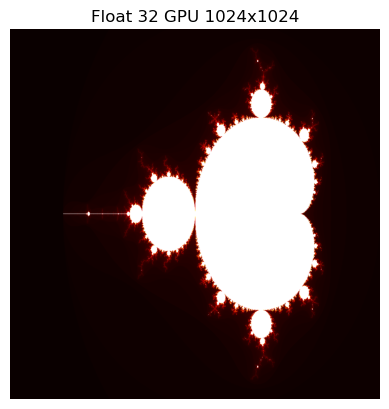

In [ ]:
import pyopencl as cl
import numpy as np
import time
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------------------
# Constants
# ----------------------------------------------------------------------------------------------------
MAX_ITER     = 200
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.25, 1.25

def do_f32_gpu(N:int, MAX_ITER:int, X_MIN:float, X_MAX:float, Y_MIN:float, Y_MAX:float, do_plot:bool) -> None:
    # ----------------------------------------------------------------------------------------------------
    # Kernel code
    # ----------------------------------------------------------------------------------------------------
    KERNEL_F32 = """
    __kernel void mandelbrot_f32(
        __global int *result,
        const float x_min, const float x_max,
        const float y_min, const float y_max,
        const int N, const int max_iter)
    {
        int col = get_global_id(0);
        int row = get_global_id(1);
        if (col >= N || row >= N) return;   // guard against over-launch

        float c_real = x_min + col * (x_max - x_min) / (float)N;
        float c_imag = y_min + row * (y_max - y_min) / (float)N;
        
        float zr = 0.0f, zi = 0.0f;
        int count = 0;
        while (count < max_iter && zr*zr + zi*zi <= 4.0f) {
            float tmp = zr*zr - zi*zi + c_real;
            zi = 2.0f * zr * zi + c_imag;
            zr = tmp;
            count++;
        }
        result[row * N + col] = count;
    }
    """

    ctx = cl.create_some_context(interactive=False)
    print(f'Using device: {ctx.devices[0].name}')

    queue     = cl.CommandQueue(ctx)
    prog      = cl.Program(ctx, KERNEL_F32).build()
    image     = np.zeros((N, N), dtype=np.int32)
    image_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image.nbytes)

    prog.mandelbrot_f32(
        queue, (N, N), None,      # global size (N, N); let OpenCL pick local
        image_dev,
        np.float32(X_MIN), np.float32(X_MAX),
        np.float32(Y_MIN), np.float32(Y_MAX),
        np.int32(N), np.int32(MAX_ITER),
    )

    cl.enqueue_copy(queue, image, image_dev)
    queue.finish()

    # --- Warm up (first launch triggers a kernel compile) ---
    prog.mandelbrot_f32(queue, (64, 64), None, image_dev,
                    np.float32(X_MIN), np.float32(X_MAX),
                    np.float32(Y_MIN), np.float32(Y_MAX),
                    np.int32(64), np.int32(MAX_ITER))
    queue.finish()

    # --- Time the real run ---
    t0 = time.perf_counter()
    prog.mandelbrot_f32(queue, (N, N), None, image_dev,
                    np.float32(X_MIN), np.float32(X_MAX),
                    np.float32(Y_MIN), np.float32(Y_MAX),
                    np.int32(N), np.int32(MAX_ITER))
    queue.finish()
    elapsed = time.perf_counter() - t0

    cl.enqueue_copy(queue, image, image_dev)
    queue.finish()

    print(f"Float 32 GPU {N}x{N}: {elapsed*1e3:.1f} ms")

    if do_plot:
        plt.title(f'Float 32 GPU {N}x{N}'); plt.imshow(image, cmap='hot', origin='lower'); plt.axis('off')
        plt.savefig("mandelbrot_f32_gpu.png", dpi=150, bbox_inches='tight')

    return elapsed

do_f32_gpu(N=1024, MAX_ITER=MAX_ITER, X_MIN=X_MIN, X_MAX=X_MAX, Y_MIN=Y_MIN, Y_MAX=Y_MAX, do_plot=True)


*GPU f32 runtime*

Float 32 GPU 1024x1024: 0.6 ms 0.6 ms

##### Milestone 2: **Float32 vs Float64**

Using device: NVIDIA GeForce RTX 2080 Ti
Float 32 GPU 1024x1024: 0.6 ms
Using device: NVIDIA GeForce RTX 2080 Ti
Float 64 GPU 1024x1024: 4.0 ms


C:\Users\Kim\AppData\Local\Temp\ipykernel_25588\297267242.py:65: RepeatedKernelRetrieval: Kernel 'mandelbrot_f32' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  prog.mandelbrot_f32(queue, (64, 64), None, image_dev,
C:\Users\Kim\AppData\Local\Temp\ipykernel_25588\401497543.py:79: RepeatedKernelRetrieval: Kernel 'mandelbrot_f64' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  prog.mandelbrot_f64(queue, (64, 64), None, image_dev,


Using device: NVIDIA GeForce RTX 2080 Ti
Float 32 GPU 2048x2048: 0.8 ms
Using device: NVIDIA GeForce RTX 2080 Ti
Float 64 GPU 2048x2048: 11.8 ms
t_1024_100_ratio=6.2687
t_2048_100_ratio=14.2287


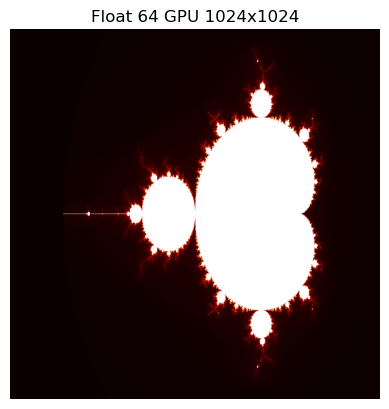

In [87]:
import pyopencl as cl
import numpy as np
import time
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------------------
# Constants
# ----------------------------------------------------------------------------------------------------
MAX_ITER     = 200
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.25, 1.25

def do_f64_gpu(N:int, MAX_ITER:int, X_MIN:float, X_MAX:float, Y_MIN:float, Y_MAX:float, do_plot:bool) -> None:
    # ----------------------------------------------------------------------------------------------------
    # Kernel code
    # ----------------------------------------------------------------------------------------------------
    KERNEL_F64 = """
    #pragma OPENCL EXTENSION cl_khr_fp64 : enable
    __kernel void mandelbrot_f64(
        __global int *result,
        const double x_min, const double x_max,
        const double y_min, const double y_max,
        const int N, const int max_iter)
    {
        int col = get_global_id(0);
        int row = get_global_id(1);
        if (col >= N || row >= N) return;

        double c_real = x_min + col * (x_max - x_min) / (double)N;
        double c_imag = y_min + row * (y_max - y_min) / (double)N;
        double z_real = 0.0, z_imag = 0.0;
        int count     = 0;
        
        while (count < max_iter && z_real*z_real + z_imag*z_imag <= 4.0)
        {
            double tmp = z_real*z_real - z_imag*z_imag + c_real;
            z_imag = 2.0 * z_real * z_imag + c_imag;
            z_real = tmp;
            count++;
        }
        result[row * N + col] = count;
    }
    """

    # ----------------------------------------------------------------------------------------------------
    # Setup context 
    # ----------------------------------------------------------------------------------------------------
    ctx = cl.create_some_context(interactive=False)
    print(f'Using device: {ctx.devices[0].name}')

    # 1. Check fp64 support
    dev = ctx.devices[0]
    if 'cl_khr_fp64' not in dev.extensions:
        raise RuntimeError('No native fp64 -- Apple Silicon: emulated, expect large slowdown')

    queue = cl.CommandQueue(ctx)
    prog  = cl.Program(ctx, KERNEL_F64).build()

    image = np.zeros((N, N), dtype=np.int32)
    image_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image.nbytes)

    prog.mandelbrot_f64(
        queue, (N, N), None,      # global size (N, N); let OpenCL pick local
        image_dev,
        np.float64(X_MIN), np.float64(X_MAX),
        np.float64(Y_MIN), np.float64(Y_MAX),
        np.int32(N), np.int32(MAX_ITER),
    )

    cl.enqueue_copy(queue, image, image_dev)
    queue.finish()


    # ----------------------------------------------------------------------------------------------------
    # Warm up and run mandelbrot
    # ----------------------------------------------------------------------------------------------------

    # --- Warm up (first launch triggers a kernel compile) ---
    prog.mandelbrot_f64(queue, (64, 64), None, image_dev,
                    np.float64(X_MIN), np.float64(X_MAX),
                    np.float64(Y_MIN), np.float64(Y_MAX),
                    np.int32(64), np.int32(MAX_ITER))
    queue.finish()

    # --- Time the real run ---
    t0 = time.perf_counter()
    prog.mandelbrot_f64(queue, (N, N), None, image_dev,
                    np.float64(X_MIN), np.float64(X_MAX),
                    np.float64(Y_MIN), np.float64(Y_MAX),
                    np.int32(N), np.int32(MAX_ITER))
    queue.finish()
    elapsed = time.perf_counter() - t0

    cl.enqueue_copy(queue, image, image_dev)
    queue.finish()

    print(f"Float 64 GPU {N}x{N}: {elapsed*1e3:.1f} ms")

    if do_plot:
        plt.title(f'Float 64 GPU {N}x{N}'); plt.imshow(image, cmap='hot', origin='lower'); plt.axis('off')
        plt.savefig("mandelbrot_f64_gpu.png", dpi=150, bbox_inches='tight')

    return elapsed

t_1024_32_100 = do_f32_gpu(N=1024, MAX_ITER=MAX_ITER, X_MIN=X_MIN, X_MAX=X_MAX, Y_MIN=Y_MIN, Y_MAX=Y_MAX, do_plot=False)
t_1024_64_100 = do_f64_gpu(N=1024, MAX_ITER=MAX_ITER, X_MIN=X_MIN, X_MAX=X_MAX, Y_MIN=Y_MIN, Y_MAX=Y_MAX, do_plot=True)
t_2048_32_100 = do_f32_gpu(N=2048, MAX_ITER=MAX_ITER, X_MIN=X_MIN, X_MAX=X_MAX, Y_MIN=Y_MIN, Y_MAX=Y_MAX, do_plot=False)
t_2048_64_100 = do_f64_gpu(N=2048, MAX_ITER=MAX_ITER, X_MIN=X_MIN, X_MAX=X_MAX, Y_MIN=Y_MIN, Y_MAX=Y_MAX, do_plot=False)

t_1024_100_ratio = t_1024_64_100 / t_1024_32_100
t_2048_100_ratio = t_2048_64_100 / t_2048_32_100
print(f'{t_1024_100_ratio=:.4f}')
print(f'{t_2048_100_ratio=:.4f}')


###### Compare speed and image quality

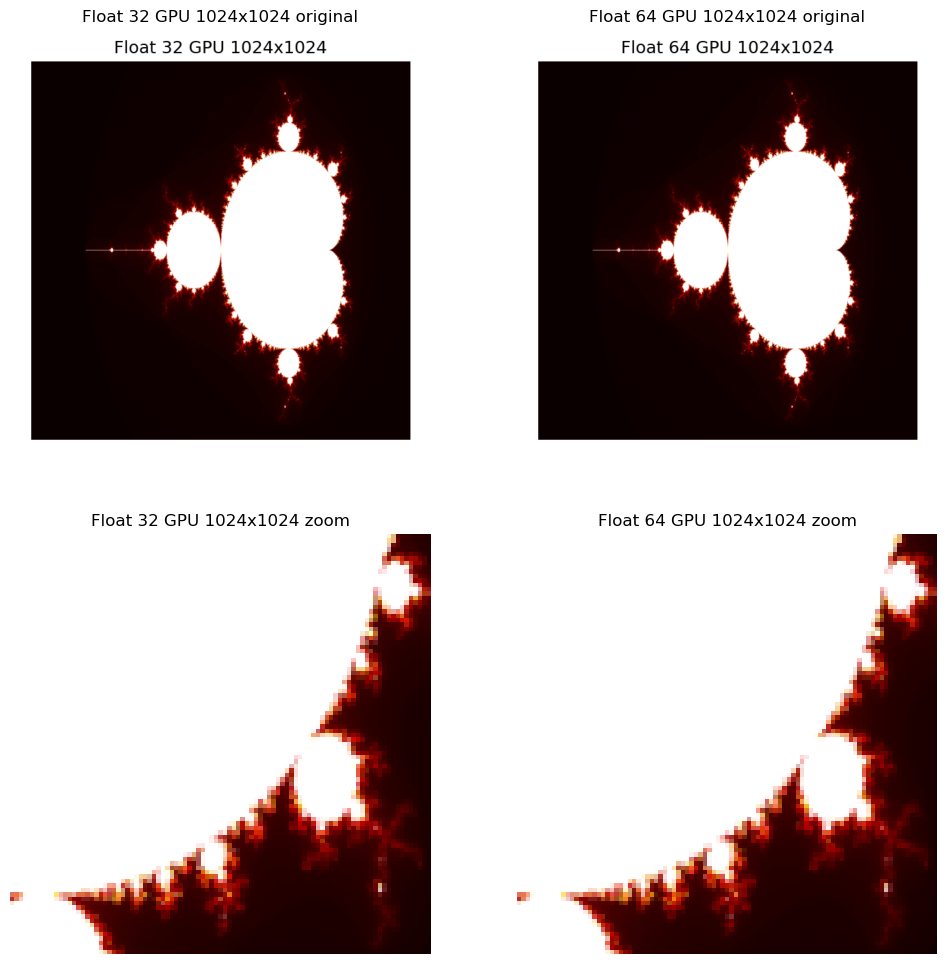

In [88]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('mandelbrot_f32_gpu.png')
img2 = mpimg.imread('mandelbrot_f64_gpu.png')

# Zoom areas
x1, x2 = 385, 480
y1, y2 = 385, 480

zoom1 = img1[y1:y2, x1:x2]
zoom2 = img2[y1:y2, x1:x2]

fig, ax = plt.subplots( 2,2, figsize=(12,12) )

ax[0,0].imshow(img1)
ax[0,0].set_title('Float 32 GPU 1024x1024 original')
ax[0,0].axis('off')
ax[0,1].imshow(img2)
ax[0,1].set_title('Float 64 GPU 1024x1024 original')
ax[0,1].axis('off')

# Zoom
ax[1,0].imshow(zoom1)
ax[1,0].set_title('Float 32 GPU 1024x1024 zoom')
ax[1,0].axis('off')
ax[1,1].imshow(zoom2)
ax[1,1].set_title('Float 64 GPU 1024x1024 zoom')
ax[1,1].axis('off')

plt.show()


###### Is the measured speed ratio consistent with your Roofline prediction?

NVIDIA Geforce RTX 2080 Ti specs according to link: [2080_ti_specs](https://www.techpowerup.com/gpu-specs/geforce-rtx-2080-ti.c3305)

*Theoretical performance & memory (from link)*
* FP32: $13.45$ TFLOPS
* FP64: $0.42$ TFLOPS
* Memory Bandwidth: $616.0$ GB/s

$$
ratio=\frac{FP32}{FP64} \approx 32
$$

This number actually means that 64-bit floating points will result in up to 32x slowdown compared to 32-bit floating points, but only if we assume that the kernel is compute-bound and not memory-bound.

We can also determine the ridge point for e.g. 32 bit floats for RTX 2080 Ti

$$
ridge_{f32}=\frac{13.45 \cdot 10^{12}}{616 \cdot 10^{9}} = 21.834 FLOPs/byte
$$

*Performance in practice (from time measurements above)*

| N   | f32 [ms] | f64 [ms] | ratio |
| -------- | ------- | ------- | ------- |
| 1024    | 0.6ms | 4.0ms      | 6.667 |
| 2048    | 0.8ms  | 11.8ms   | 14.75 |

The ratio between theoretical FP32 and FP64 peak performance is compared to the runtime ratios from the previous cell executions.
The numbers suggests that switching between FP32 and FP64 only results in a slowdown of ~7-15x and not 32.

The real question is whether the kernel computing the Mandelbrot set in this case is memory or compute bound.
If we study the kernel code:

```c
        int col = get_global_id(0);
        int row = get_global_id(1);
        if (col >= N || row >= N) return;

        double c_real = x_min + col * (x_max - x_min) / (double)N;
        double c_imag = y_min + row * (y_max - y_min) / (double)N;
        double z_real = 0.0, z_imag = 0.0;
        int count     = 0;
        
        while (count < max_iter && z_real*z_real + z_imag*z_imag <= 4.0)
        {
            double tmp = z_real*z_real - z_imag*z_imag + c_real;
            z_imag = 2.0 * z_real * z_imag + c_imag;
            z_real = tmp;
            count++;
        }
        result[row * N + col] = count;
```

The amount of memory we repeatedly write back to the host is centered around the integer variable *count*. An integer is 4 bytes and the grid size is NxN. If we have e.g. N=1024 we have: 

$$
1024 \cdot 1024 \cdot 4 \approx 4MB
$$

If we look into the amount of FLOPS in the Mandelbrot computation, we can count them by looking at the operations:
* z_real*z_real + z_imag*z_imag = 3 FLOPS
* z_real*z_real - z_imag*z_imag + c_real = 4 FLOPS
* 2.0 * z_real * z_imag + c_imag = 3 FLOPS
In total we have 10 FLOPS per iteration and, when pixels are not escaping we stop at 200 iterations, so we use 2000 FLOPS for pixels that do not escape.
We can compute the arithmetic intensity based on this as:

$$
AI = \frac{2000 FLOPS}{4 bytes} = 500FLOPs/byte
$$

Comparing this number against the aforementioned 21.834 FLOPs/byte, clearly suggests that Mandelbrot is compute bound. Of course, we have to keep in mind that the 500 FLOPs/byte is for the pixels that do not escape! The arithmetic intensity will of course be smaller for pixels that escape quickly and this will bring the average arithmetic intensity down, but probably still higher than the ridge point.
Interestingly, we do not hit the theoretical roof of 32, suggesting we are not fully utilizing the GPU. This could perhaps be due to the pixels escaping at different counts.
One last observation is also that the ratio actually increases, when we increase the resolution N=2048. It changes from 6.667 to 14.75, suggesting better GPU utilization. 

To conclude, the slowdown in practice is lower than the theoretical maximum performance of 32, yet this is still consistent with the Roofline model.
We saw that the arithmetic intensity is compute-bound based on the calculation that showed that unescaped pixels lies at 500 FLOPs/byte, which is far to the right of the ridge point in this case. This tells us that performance is limited by a compute ceiling as predicted by the Roofline model.

##### Milestone 3: **Benchmark GPU vs Earlier Results**

In [89]:
import pyopencl as cl
import numpy as np

# ----------------------------------------------------------------------------------------------------
# Kernel codes
# ----------------------------------------------------------------------------------------------------
KERNEL_F32 = """
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    int col = get_global_id(0);
    int row = get_global_id(1);
    if (col >= N || row >= N) return;   // guard against over-launch

    float c_real = x_min + col * (x_max - x_min) / (float)N;
    float c_imag = y_min + row * (y_max - y_min) / (float)N;
    
    float zr = 0.0f, zi = 0.0f;
    int count = 0;
    while (count < max_iter && zr*zr + zi*zi <= 4.0f) {
        float tmp = zr*zr - zi*zi + c_real;
        zi = 2.0f * zr * zi + c_imag;
        zr = tmp;
        count++;
    }
    result[row * N + col] = count;
}
"""

KERNEL_F64 = """
#pragma OPENCL EXTENSION cl_khr_fp64 : enable
__kernel void mandelbrot(
    __global int *result,
    const double x_min, const double x_max,
    const double y_min, const double y_max,
    const int N, const int max_iter)
{
    int col = get_global_id(0);
    int row = get_global_id(1);
    if (col >= N || row >= N) return;

    double c_real = x_min + col * (x_max - x_min) / (double)N;
    double c_imag = y_min + row * (y_max - y_min) / (double)N;
    double z_real = 0.0, z_imag = 0.0;
    int count     = 0;
    
    while (count < max_iter && z_real*z_real + z_imag*z_imag <= 4.0)
    {
        double tmp = z_real*z_real - z_imag*z_imag + c_real;
        z_imag = 2.0 * z_real * z_imag + c_imag;
        z_real = tmp;
        count++;
    }
    result[row * N + col] = count;
}
"""

# ----------------------------------------------------------------------------------------------------
# Methods for setup & running kernels
# ----------------------------------------------------------------------------------------------------
def init_kernel(kernel_src:str) -> dict:
    kernel_obj              = {}
    kernel_obj['ctx']       = cl.create_some_context(interactive=False)
    kernel_obj['queue']     = cl.CommandQueue(kernel_obj['ctx'])
    kernel_obj['prog']      = cl.Program(kernel_obj['ctx'], kernel_src).build()
    kernel_obj['image']     = np.zeros((N, N), dtype=np.int32)
    kernel_obj['image_dev'] = cl.Buffer(kernel_obj['ctx'], cl.mem_flags.WRITE_ONLY, kernel_obj['image'].nbytes)
    return kernel_obj

def run_mandelbrot_f32(kernel_obj, N:int, MAX_ITER:int, X_MIN:float, X_MAX:float, Y_MIN:float, Y_MAX:float) -> np.ndarray:
    kernel_obj['prog'].mandelbrot(
        kernel_obj['queue'], (N, N), None,      # global size (N, N); let OpenCL pick local
        kernel_obj['image_dev'],
        np.float32(X_MIN), np.float32(X_MAX),
        np.float32(Y_MIN), np.float32(Y_MAX),
        np.int32(N), np.int32(MAX_ITER),
    )

    # Do not include time it takes to write back result to host
    # cl.enqueue_copy(kernel_obj['queue'], kernel_obj['image'], kernel_obj['image_dev'])
    kernel_obj['queue'].finish()

def run_mandelbrot_f64(kernel_obj, N:int, MAX_ITER:int, X_MIN:float, X_MAX:float, Y_MIN:float, Y_MAX:float) -> np.ndarray:
    kernel_obj['prog'].mandelbrot(
        kernel_obj['queue'], (N, N), None,      # global size (N, N); let OpenCL pick local
        kernel_obj['image_dev'],
        np.float64(X_MIN), np.float64(X_MAX),
        np.float64(Y_MIN), np.float64(Y_MAX),
        np.int32(N), np.int32(MAX_ITER),
    )

    # Do not include time it takes to write back result to host
    # cl.enqueue_copy(kernel_obj['queue'], kernel_obj['image'], kernel_obj['image_dev'])
    kernel_obj['queue'].finish()


###### **Compare Mandelbrot Implementations**

C:\Users\Kim\AppData\Local\Temp\ipykernel_25588\2519732962.py:74: RepeatedKernelRetrieval: Kernel 'mandelbrot' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  kernel_obj['prog'].mandelbrot(
C:\Users\Kim\AppData\Local\Temp\ipykernel_25588\2519732962.py:87: RepeatedKernelRetrieval: Kernel 'mandelbrot' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  kernel_obj['prog'].mandelbrot(


0.0007867
0.0007252
0.0006091
0.0033182
0.0020642
0.0019104
('Naive', 'Numpy', 'Numba', 'Multiprocessing', 'Dask Local', 'Dask Strato', 'GPU f32', 'GPU f64')
(10.26, 0.87, 0.075, 0.028, 0.073, 0.065, 0.0007252, 0.0020642)


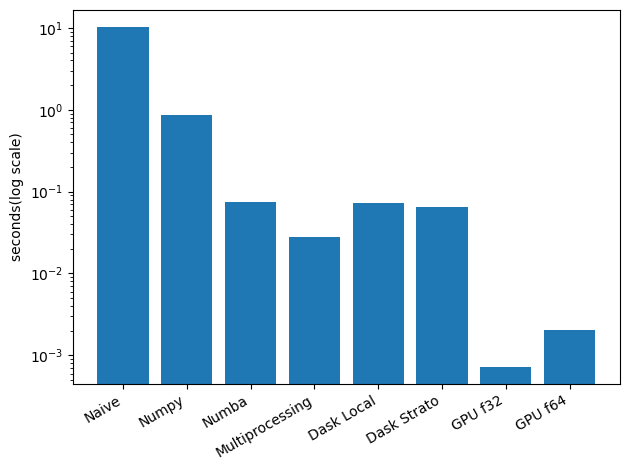

<Figure size 640x480 with 0 Axes>

In [90]:
import statistics
import time
import matplotlib.pyplot as plt

def timed(fn, runs:int=3):
    # warmup
    for _ in range(2):
        fn()

    ts = []
    for _ in range(runs):
        t0 = time.perf_counter_ns()
        fn()
        elapsed = (time.perf_counter_ns() - t0) / 1e9
        print(elapsed)
        ts.append(elapsed)
    return statistics.median(ts)

N, MAX_ITER = 1024, 100
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.25, 1.25

# gpu results
kernel_obj = init_kernel(KERNEL_F32)
gpu_f32    = timed(lambda: run_mandelbrot_f32(kernel_obj, N, MAX_ITER, X_MIN, X_MAX, Y_MIN, Y_MAX))
kernel_obj = init_kernel(KERNEL_F64)
gpu_f64    = timed(lambda: run_mandelbrot_f64(kernel_obj, N, MAX_ITER, X_MIN, X_MAX, Y_MIN, Y_MAX))

results = { 
    "Naive": 10.260,
    "Numpy": 0.870,
    "Numba": 0.075,
    "Multiprocessing": 0.028,
    "Dask Local": 0.073,
    "Dask Strato": 0.065,
    "GPU f32": gpu_f32,
    "GPU f64": gpu_f64
}

names, times = zip(*results.items())

print(names)
print(times)

plt.figure()
plt.bar(names, times, log=True)
plt.ylabel("seconds(log scale)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
plt.savefig("benchmark_mp3.png", dpi=150)


*Where does GPU sit relative to Numba? To naive Python?*

GPU float 32 is the fastest compared to all the previous Mandelbrot implementations.

---

# Performance table

##### Addition of missing 32-bit Float for Numba implementation

I have been missing the performance result for Numba 32-bit float from MP1 and instead the Numba result was based on 64-bit float.
As a result, I executed the code again from my old laptop to produce result, so it can be compared against the earlier Mandelbrot implementations.

The code used is still identical to the one used in MP1.
In this report, I have only shown the relevant parts of the code from MP1.

In [91]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import statistics
import time

import numpy as np
from numba import jit, njit, prange

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
width          = 1024
height         = 1024
x_min          = -2.0
x_max          = 1.0
y_min          = -1.5
y_max          = 1.5
max_iteration  = 100 # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------
def create_grid(width, height, dtype=np.float64):
    x = np.linspace(x_min, x_max, width).astype(dtype)
    y = np.linspace(y_min, y_max, height).astype(dtype)
    X, Y = np.meshgrid(x,y)
    C = X + 1j * Y # Form complex numbers

    print(f'dtype: {dtype}, dtype: c[0,0] dtype: { type( C[0, 0] )}')
    return C

@njit(parallel=True, fastmath=True)
def mandelbrot_naive_numba(C_grid) -> None:
    '''
    Compute Mandelbrot set by iterating over all pixels and applying mandelbrot function on corresponding complex number.
    '''
    mandelbrot_set = np.zeros(C_grid.shape, dtype=np.int32)

    # Loop over all grid complex values and check for divergence with mandelbrot function
    height, width = C_grid.shape
    for i in range(height):
        for j in range(width):
            c = C_grid[i, j]
            
            # Initialize z value before loop
            z = 0

            converged = True # Just used to check if we break out of loop
            for n in range(max_iteration):
                # compute: z_{n+1} = z_n^2 + c
                z = z*z + c

                # Check if new z value exceeds 2
                if ( z.real*z.real + z.imag*z.imag ) > 4: # We don't really need to do the sqrt here, as we know sqrt of the result is 2 anyway...
                    mandelbrot_set[i,j] = n
                    converged = False
                    break
            
            if converged:
                mandelbrot_set[i,j] = max_iteration
    
    return mandelbrot_set

def benchmark ( func , * args , n_runs =3) -> tuple:
    """ Time func , return median of n_runs . """
    times = []
    for _ in range ( n_runs ):
        t0 = time . perf_counter ()
        result = func (* args )
        times . append ( time . perf_counter () - t0 )
    
    median_t = statistics . median ( times )
    
    print (f" Median : { median_t :.4f}s "
        f"( min ={ min( times ):.4f}, max ={ max( times ):.4f})")
    
    return median_t, result


Using the Numba implementation for float32

In [ ]:
import platform

# System information from old laptop
print(f'System : {platform.system()}')
print(f'Node : {platform.node()}')
print(f'Machine : {platform.machine()}')
print(f'Processor : {platform.processor()}')

C_grid = create_grid(1024, 1024, dtype=np.float32)
t_numba, _ = benchmark ( mandelbrot_naive_numba, C_grid, n_runs=3)
print (f" Numba : { t_numba :.3f}s ({ 10.2604 / t_numba :.1f}x)")


Output from old laptop

```python
System : Darwin
Node : KimsMacBookPro
Machine : x86_64
Processor : i386
dtype: <class 'numpy.float32'>, dtype: c[0,0] dtype: <class 'numpy.complex64'>
 Median : 0.0764s ( min =0.0747, max =1.3773)
 Numba : 0.076s (134.3x)
```

##### Complete performance table

**Benchmark Table (based on results from MP1 & MP2 reports, all experiments were carried out with 1024x1024 as grid size)**
| Version   | Time | Speedup | Workers | Resolution |
| -------- | ------- | ------- | ------- | ------- |
| Naive    | 10.260s | 1x      | 1       | 1024x1024 |
| Numpy    | 0.870s  | 11.8x   | 1       | 1024x1024 |
| Numba F32    | 0.076s  | 135x  | 1       | 1024x1024 |
| Numba F64    | 0.075s  | 136.9x  | 1       | 1024x1024 |
| Numba + multiprocessing | 0.028s  | 366.4x  | 4| 1024x1024 |
| Dask Local | 0.073s  | 140.5x  | 4| 1024x1024 |
| Dask Strato | 0.065s  | 157.84x  | 4| 1024x1024 |
| Dask Strato | 0.588s  | ...  | 4| 4096x4096 |
| GPU F32 | 0.0007252s  | 14147.821x  | ...| 1024x1024 |
| GPU F64 | 0.0020642s  | 4970.449x  | ...| 1024x1024 |


---

# Reflection

My GPU results based on both float32 and float64 indicated a very large speedup compared to all the other Mandelbrot implementations, which raises an interesting question whether the GPU is always the right choice. The answer is that it depends on the problem to solve. Computing the Mandelbrot set is a good example of a compute-bound problem in which GPUs are very efficient at solving compared to a CPU. However, not all problems are compute-bound and this is addressed in the Roofline model, which provides an overview of whether a program is compute or memory bound. If a computing problem involves a very large portion of data that must be moved such as streaming data and not much computation, then the bandwidth of the memory bus between the GPU and CPU becomes a bottleneck that costs performance. More specifically, it becomes expensive to copy data between the GPU and CPU. In this regard, it would make more sense to just move the entire execution onto the CPU and use Numba or multiprocessing to solve the problem and thereby avoid the memory bottleneck entirely. Another thing to mention, is also that in order to execute code efficiently on a GPU, the work items must be independent. If the code is very sequential and branchy, using a GPU is not efficient.

Creating the test suite required me to refactor the implementations a bit. More specifically, my goal was to split the code into smaller modular functions in order to better test individual components of the code. Initially, the code was designed such that it was doing multiple things in one place, which makes it very difficult to test. I learned that for me it made more sense to write the test cases before I refactored the code, because I wanted to have an understanding of what I expected of the implementations first. Afterwards, it was a question of modifying the implementations such that the output of the functions to test was geared towards my test cases.

Documenting all the Mandelbrot implementations was a very good process, as it forced me to better understand what is actually going on in the code and also to make the implementations easier for others to read. Looking back, it would have been smart to add docstrings and type hints first because this really helps to define the responsibility of each function. I am also certain that by documenting the functions first would likely have reduced the amount of refactoring that I had to do.